In [1]:
# Importing dataset and deviding dataset into train and test sets. 
 
import torch
import numpy as np
import random
import os
import pandas as pd
import requests
import io
import warnings
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from rdkit import Chem

# Setup 
warnings.filterwarnings("ignore")
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)


if not os.path.exists('qm9.csv'):
    print("Downloading QM9 dataset...")
    url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/qm9.csv"
    response = requests.get(url)
    df = pd.read_csv(io.BytesIO(response.content))
    df.to_csv('qm9.csv', index=False)
else:
    df = pd.read_csv('qm9.csv')

df = df.head(10000) # Use a subset for faster processing.


molecule_graphs = []

for idx, row in df.iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol is None: continue
    
    x = torch.tensor([[a.GetAtomicNum(), a.GetDegree(), int(a.GetIsAromatic()), 
                       int(a.GetHybridization()), a.GetValence(Chem.ValenceType.IMPLICIT), 
                       a.GetFormalCharge()] for a in mol.GetAtoms()], dtype=torch.float)
    
    src, tgt = [], []
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        src.extend([i, j]); tgt.extend([j, i])
    edge_index = torch.tensor([src, tgt], dtype=torch.long)
    
    y = torch.tensor([row['gap']], dtype=torch.float)
    molecule_graphs.append(Data(x=x, edge_index=edge_index, y=y))

train_loader = DataLoader(molecule_graphs[:8000], batch_size=32, shuffle=True)
test_loader = DataLoader(molecule_graphs[8000:], batch_size=32)

print("Dataset loaded and split into train/test sets.")


c:\Users\Lenovo\Desktop\LieColorGNN\stereovenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset loaded and split into train/test sets.


In [2]:
# Basic GNN architecture.

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class GNN(nn.Module): 
    def __init__(self): 
        super(GNN, self).__init__() 
        # 6 is the number of input features we defined in Cell 1
        self.conv1 = GCNConv(6, 64) # First GCN layer that takes 6 input features and outputs 64 features for each node.
        self.conv2 = GCNConv(64, 64) # Second GCN layer.
        self.fc = nn.Linear(64, 1)  # Final fully connected layer.

    def forward(self, data):  # Defining forward pass of the GNN. 
        x, edge_index = data.x, data.edge_index # Get the node features and edge indices from the input data.
        
        # Message passing layers
        x = self.conv1(x, edge_index) 
        x = F.relu(x)   
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        x = global_mean_pool(x, data.batch) # Global mean pooling to get a graph-level representation from node features.
        return self.fc(x).squeeze(1) # Final output is the predicted energy gap for each molecule.

model = GNN()

print("GNN architecture defined successfully.")

GNN architecture defined successfully.


In [3]:
# Training and evaluation of the basic GNN model.

import torch.nn as nn
from sklearn.metrics import mean_absolute_error, r2_score

optimizer = torch.optim.Adam(model.parameters(), lr=0.005) # Adam optimizer with a learning rate of 0.005.
criterion = nn.MSELoss()  # Mean Squared Error loss function for regression.

# Training
model.train()
for epoch in range(100): 
    for batch in train_loader: 
        optimizer.zero_grad()
        out = model(batch) # Forward pass: Get the model's predictions for the current batch of data.
        loss = criterion(out, batch.y) # Compute the loss by comparing the model's predictions with the true energy gap values. 
        loss.backward()  # Backward pass: Compute gradients of the loss with respect to model parameters. 
        optimizer.step()  # Update model parameters.

# Evaluation
model.eval()
y_true, y_pred = [], [] # Lists to store true and predicted values for evaluation.

with torch.no_grad(): # Disable gradient calculation for evaluation to save memory and computation.
    for batch in test_loader:
        out = model(batch)  # Get the model's predictions for the test batch.
        y_true.extend(batch.y.numpy()) # Append the true energy gap values to the y_true list.
        y_pred.extend(out.numpy()) # Append the predicted energy gap values to the y_pred list.

mae = mean_absolute_error(y_true, y_pred) # Calculate Mean Absolute Error between true and predicted values.
r2 = r2_score(y_true, y_pred) # Calculate R² Score to evaluate how well the model's predictions fit the true values.
print("2D GNN Results")
print(f"MAE: {mae:.4f} Hartree")
print(f"R² Score: {r2:.4f}")

2D GNN Results
MAE: 0.0156 Hartree
R² Score: 0.8122


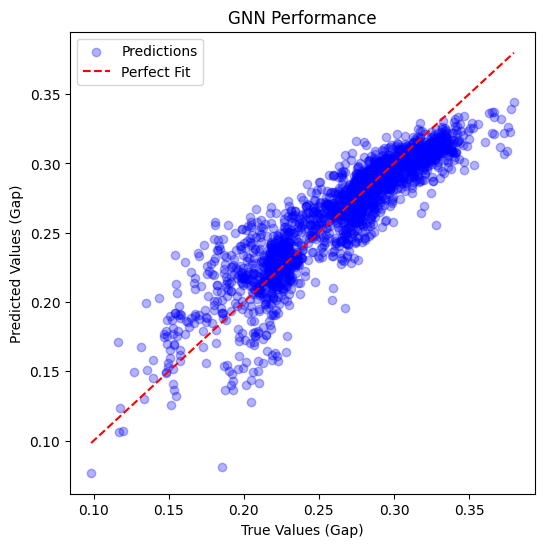

In [4]:
# Visualization of basic GNN performance.

import matplotlib.pyplot as plt

def plot_results(y_true, y_pred, title="GNN Performance"):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.3, color='blue', label='Predictions')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--', label='Perfect Fit')
    plt.xlabel("True Values (Gap)")
    plt.ylabel("Predicted Values (Gap)")
    plt.title(title)
    plt.legend()
    plt.show()

plot_results(y_true, y_pred)

In [5]:
# Generating 3D data

from rdkit.Chem import AllChem

# 3D Data
molecule_graphs_3d = []

for idx, row in df.iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol is None: continue
    
    mol_3d = Chem.AddHs(mol) # Generate 3D coordinates
    
    if AllChem.EmbedMolecule(mol_3d, AllChem.ETKDG()) == -1:  # Check if embedding succeeded; EmbedMolecule returns -1 on failure
        continue # Skip molecules that couldn't be embedded in 3D
        
    conf = mol_3d.GetConformer()
    pos = torch.tensor([conf.GetAtomPosition(i) for i in range(mol_3d.GetNumAtoms())], dtype=torch.float)
    
    # 2D Node features
    x = torch.tensor([[a.GetAtomicNum(), a.GetDegree(), int(a.GetIsAromatic()), 
                       int(a.GetHybridization()), a.GetValence(Chem.ValenceType.IMPLICIT), 
                       a.GetFormalCharge()] for a in mol_3d.GetAtoms()], dtype=torch.float)
    
    
    src, tgt = [], []
    for b in mol_3d.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        src.extend([i, j]); tgt.extend([j, i])
    edge_index = torch.tensor([src, tgt], dtype=torch.long)
    
    row_idx, col_idx = edge_index
    dist = (pos[row_idx] - pos[col_idx]).norm(dim=1).unsqueeze(1) # Calculate distances between connected atoms.
    
    y = torch.tensor([row['gap']], dtype=torch.float) # Target variable is the energy gap.
    molecule_graphs_3d.append(Data(x=x, edge_index=edge_index, edge_attr=dist, y=y, pos=pos)) 
    # Create a Data object that includes node features, edge indices, edge attributes (distances), target variable, and 3D positions.


train_loader_3d = DataLoader(molecule_graphs_3d[:8000], batch_size=32, shuffle=True) # Create a DataLoader for the training set of 3D graphs, using the first 8000 molecules.
test_loader_3d = DataLoader(molecule_graphs_3d[8000:], batch_size=32) # Create a DataLoader for the test set of 3D graphs, using the remaining molecules.

# 3D-aware graph dataset is ready.

In [6]:
# LieGNN architecture.
# GNN + Lie Symmetry

import torch.nn as nn
from torch_geometric.nn import GINEConv, global_mean_pool

class LieGNN(nn.Module):
    def __init__(self):
        super(LieGNN, self).__init__()

        self.conv1 = GINEConv(
            nn.Sequential(nn.Linear(6, 64), nn.ReLU(), nn.Linear(64, 64)), 
            edge_dim=1
        )
        self.conv2 = GINEConv(
            nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 64)), 
            edge_dim=1
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, data):
        x = self.conv1(data.x, data.edge_index, data.edge_attr)
        x = x.relu()
        x = self.conv2(x, data.edge_index, data.edge_attr)
        x = x.relu()
        
        x = global_mean_pool(x, data.batch)
        return self.fc(x).squeeze(1)

model_3d = LieGNN()

print("LieGNN architecture defined successfully.")

LieGNN architecture defined successfully.


In [7]:
# Improved LieGNN architecture (LieGNN_V2) with deeper layers and better activation functions.

import torch.nn as nn
import torch.nn.functional as F  
from torch_geometric.nn import GINEConv, global_mean_pool

class LieGNN_V2(nn.Module): # Define a new class for the improved LieGNN architecture.
    def __init__(self):
        super(LieGNN_V2, self).__init__()
        # Deeper architecture
        self.conv1 = GINEConv(nn.Sequential(nn.Linear(6, 128), nn.SiLU(), nn.Linear(128, 128)), edge_dim=1)
        self.conv2 = GINEConv(nn.Sequential(nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 128)), edge_dim=1)
        self.conv3 = GINEConv(nn.Sequential(nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 128)), edge_dim=1)
        self.fc = nn.Linear(128, 1)

    def forward(self, data):
        x = F.silu(self.conv1(data.x, data.edge_index, data.edge_attr))
        x = F.silu(self.conv2(x, data.edge_index, data.edge_attr))
        x = F.silu(self.conv3(x, data.edge_index, data.edge_attr))
        
        x = global_mean_pool(x, data.batch)
        return self.fc(x).squeeze(1)

model_3d_v2 = LieGNN_V2()

print("Improved LieGNN architecture defined successfully.")

Improved LieGNN architecture defined successfully.


 LieGNN V2 
MAE: 0.0106 Hartree
R² Score: 0.9138


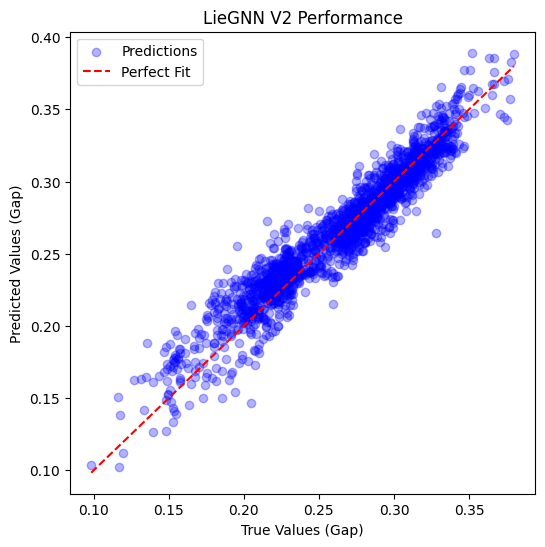

In [8]:
# Training and evaluation of the improved LieGNN (LieGNN_V2) architecture.

import torch.nn as nn
from sklearn.metrics import mean_absolute_error, r2_score

# Setup Optimizer and Criterion
# We use a slightly lower learning rate (0.001) to help the deeper model converge smoothly

optimizer_3d_v2 = torch.optim.Adam(model_3d_v2.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Training
model_3d_v2.train()
for epoch in range(100):
    for batch in train_loader_3d:
        optimizer_3d_v2.zero_grad()
        out = model_3d_v2(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer_3d_v2.step()

# Evaluation
model_3d_v2.eval()
y_true_3d_v2, y_pred_3d_v2 = [], []

with torch.no_grad():
    for batch in test_loader_3d:
        out = model_3d_v2(batch)
        y_true_3d_v2.extend(batch.y.numpy())
        y_pred_3d_v2.extend(out.numpy())

# Calculate metrics
mae_3d_v2 = mean_absolute_error(y_true_3d_v2, y_pred_3d_v2)
r2_3d_v2 = r2_score(y_true_3d_v2, y_pred_3d_v2)

print(f" LieGNN V2 ")
print(f"MAE: {mae_3d_v2:.4f} Hartree")
print(f"R² Score: {r2_3d_v2:.4f}")

# Plot LieGNN V2 performance
plot_results(y_true_3d_v2, y_pred_3d_v2, title="LieGNN V2 Performance")

Reliability Metrics
Training R²: 0.9541
Testing R²:  0.9138


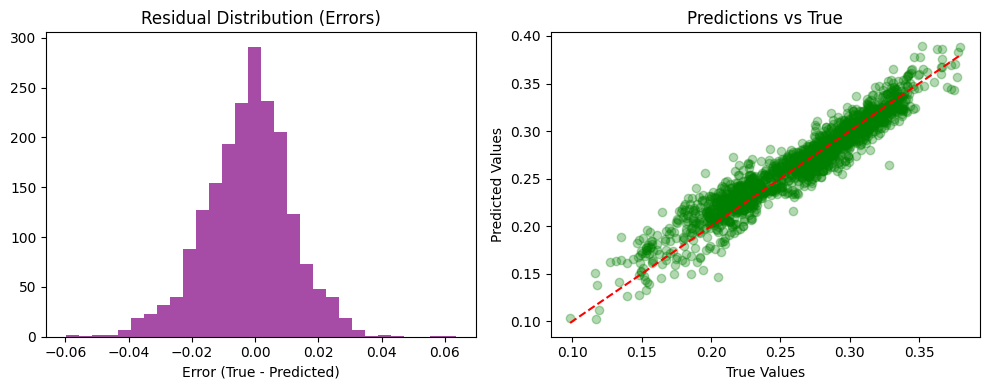

In [9]:
# Reliability check for LieGNN V2
# R² for Training and testing set should be close.

import matplotlib.pyplot as plt
import torch

def check_reliability(model, train_loader, test_loader):
    model.eval()
    
    # Comparison of Train vs Test Performance
    def get_r2(loader):
        y_true, y_pred = [], []
        with torch.no_grad():
            for batch in loader:
                out = model(batch)
                y_true.extend(batch.y.numpy())
                y_pred.extend(out.numpy())
        return r2_score(y_true, y_pred), np.array(y_true), np.array(y_pred)

    r2_train, y_train_true, y_train_pred = get_r2(train_loader)
    r2_test, y_test_true, y_test_pred = get_r2(test_loader)
    
    print("Reliability Metrics")
    print(f"Training R²: {r2_train:.4f}")
    print(f"Testing R²:  {r2_test:.4f}")
    
    # Residual Analysis
    residuals = y_test_true - y_test_pred
    
    plt.figure(figsize=(10, 4))
    
    # Plots
    plt.subplot(1, 2, 1)
    plt.hist(residuals, bins=30, color='purple', alpha=0.7)
    plt.title("Residual Distribution (Errors)")
    plt.xlabel("Error (True - Predicted)")
    
    # Predicted vs True
    plt.subplot(1, 2, 2)
    plt.scatter(y_test_true, y_test_pred, alpha=0.3, color='green')
    plt.plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'r--')
    plt.title("Predictions vs True")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    
    plt.tight_layout()
    plt.show()


check_reliability(model_3d_v2, train_loader_3d, test_loader_3d)

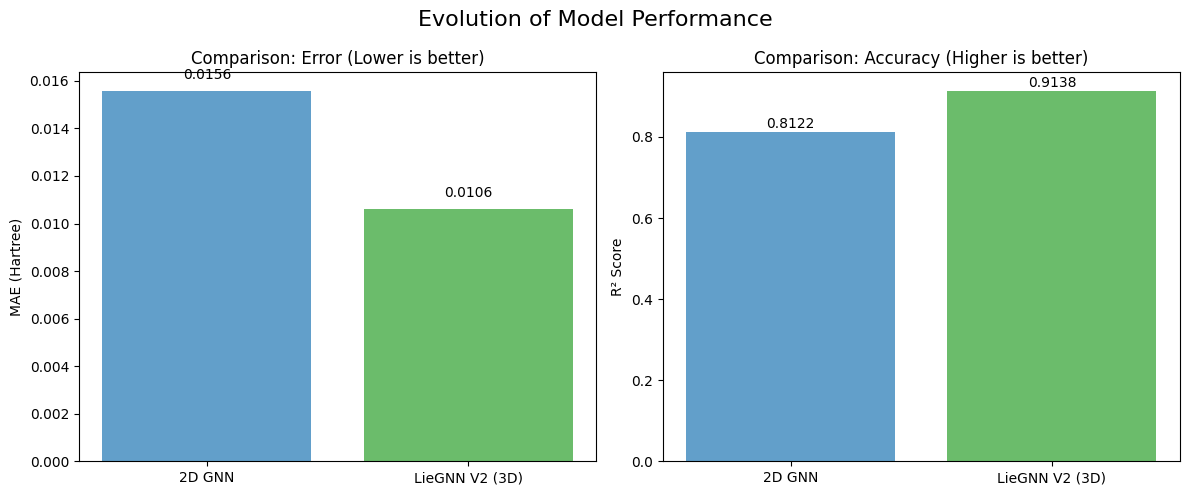

In [10]:
# Comparison graph of 2D GNN vs LieGNN V2 performance.

import matplotlib.pyplot as plt
import numpy as np

# Performance metrics
labels = ['2D GNN', 'LieGNN V2 (3D)']
mae_scores = [mae, mae_3d_v2]
r2_scores = [r2, r2_3d_v2]

x = np.arange(len(labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# MAE should be lower for better performance
ax1.bar(x, mae_scores, color=['tab:blue', 'tab:green'], alpha=0.7)
ax1.set_ylabel('MAE (Hartree)')
ax1.set_title('Comparison: Error (Lower is better)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
for i, v in enumerate(mae_scores):
    ax1.text(i, v + 0.0005, f"{v:.4f}", ha='center')

# R2 Score should be higher for better performance
ax2.bar(x, r2_scores, color=['tab:blue', 'tab:green'], alpha=0.7)
ax2.set_ylabel('R² Score')
ax2.set_title('Comparison: Accuracy (Higher is better)')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
for i, v in enumerate(r2_scores):
    ax2.text(i, v + 0.01, f"{v:.4f}", ha='center')

plt.suptitle('Evolution of Model Performance', fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
# Graph Coloring for 3D GNNs (2-distance coloring for unique color assignments.)

import networkx as nx

def get_greedy_coloring(adj_list, num_atoms):
    
    G = nx.Graph()
    G.add_nodes_from(range(num_atoms))
    
    for i, neighbors in enumerate(adj_list):
        for j in neighbors:
            G.add_edge(i, j)
    
    # Greedy Coloring
    coloring = nx.coloring.greedy_color(G, strategy='largest_first')
    
    return [coloring[i] for i in range(num_atoms)]

molecule_graphs_colored = []
threshold = 3.0  # Threshold for 'imaginary' edges (we connect atoms that are within this distance in 3D space)

for data in molecule_graphs_3d:
    num_atoms = data.x.size(0)
    # Greedy coloring for actual bonds
    adj_list = [set() for _ in range(num_atoms)] 
    src, tgt = data.edge_index
    for i, j in zip(src, tgt):
        adj_list[i].add(int(j))
    
    # Add imaginary edges based on distance and do 2-distance coloring

    pos = data.pos
    for i in range(num_atoms):
        for j in range(i + 1, num_atoms):
            dist = torch.norm(pos[i] - pos[j])
            if dist < threshold:
                adj_list[i].add(j)
                adj_list[j].add(i)
   
    colors = get_greedy_coloring(adj_list, num_atoms)  # Get colors for each atom based on the both actual and imaginary edges.
    
    color_tensor = torch.tensor(colors, dtype=torch.float).unsqueeze(1) / max(colors + [1]) # Add color as a new feature (It will be unique for each molecule.)
    
    new_x = torch.cat([data.x, color_tensor], dim=1)  # Combining the original features with the new color feature
    
    # Create new Data object
    molecule_graphs_colored.append(Data(x=new_x, edge_index=data.edge_index, 
                                       edge_attr=data.edge_attr, y=data.y, pos=data.pos))

# Colored DataLoaders
train_loader_colored = DataLoader(molecule_graphs_colored[:8000], batch_size=32, shuffle=True)
test_loader_colored = DataLoader(molecule_graphs_colored[8000:], batch_size=32)

print("Coloring complete. Molecules are now colored and ready for training.")

Coloring complete. Molecules are now colored and ready for training.


In [12]:
# LieColorGNN architecture that incorporates the new color feature into the GNN layers.

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, global_mean_pool

class LieColorGNN(nn.Module):
    def __init__(self):
        super(LieColorGNN, self).__init__()
        # Input dim are 7 (Atomic features + Color feature)
        # Edge_dim: 1 (Euclidean distance)
        self.conv1 = GINEConv(nn.Sequential(nn.Linear(7, 128), nn.SiLU(), nn.Linear(128, 128)), edge_dim=1) 
        # First GINEConv layer that takes 7 input features (6 atomic features + 1 color feature) and outputs 128 features for each node, using edge attributes (distances).

        self.conv2 = GINEConv(nn.Sequential(nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 128)), edge_dim=1)
        self.conv3 = GINEConv(nn.Sequential(nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 128)), edge_dim=1)
        self.fc = nn.Linear(128, 1)

    def forward(self, data):
        # Forward pass
        x = F.silu(self.conv1(data.x, data.edge_index, data.edge_attr))
        x = F.silu(self.conv2(x, data.edge_index, data.edge_attr))
        x = F.silu(self.conv3(x, data.edge_index, data.edge_attr))
        
        x = global_mean_pool(x, data.batch) 
        return self.fc(x).squeeze(1) 

model_lie_color = LieColorGNN()
print("LieColorGNN initialized and ready for training.")

LieColorGNN initialized and ready for training.


In [13]:
# Clear unused memory for better performance during training.

import torch
import gc

gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("Unused Memory cleared.")

Unused Memory cleared.


In [14]:
# Training LieColorGNN for 100 epochs

optimizer_lc = torch.optim.Adam(model_lie_color.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Training
model_lie_color.train()
for epoch in range(100): 
    for batch in train_loader_colored:
        optimizer_lc.zero_grad()
        out = model_lie_color(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer_lc.step()
    

# Evaluation
model_lie_color.eval()
y_true_lc, y_pred_lc = [], []
with torch.no_grad():
    for batch in test_loader_colored:
        out = model_lie_color(batch)
        y_true_lc.extend(batch.y.numpy())
        y_pred_lc.extend(out.numpy())

mae_lc = mean_absolute_error(y_true_lc, y_pred_lc)
r2_lc = r2_score(y_true_lc, y_pred_lc)

print(" LieColorGNN Results")
print(f"MAE: {mae_lc:.4f} Hartree")
print(f"R² Score: {r2_lc:.4f}")

 LieColorGNN Results
MAE: 0.0119 Hartree
R² Score: 0.8945


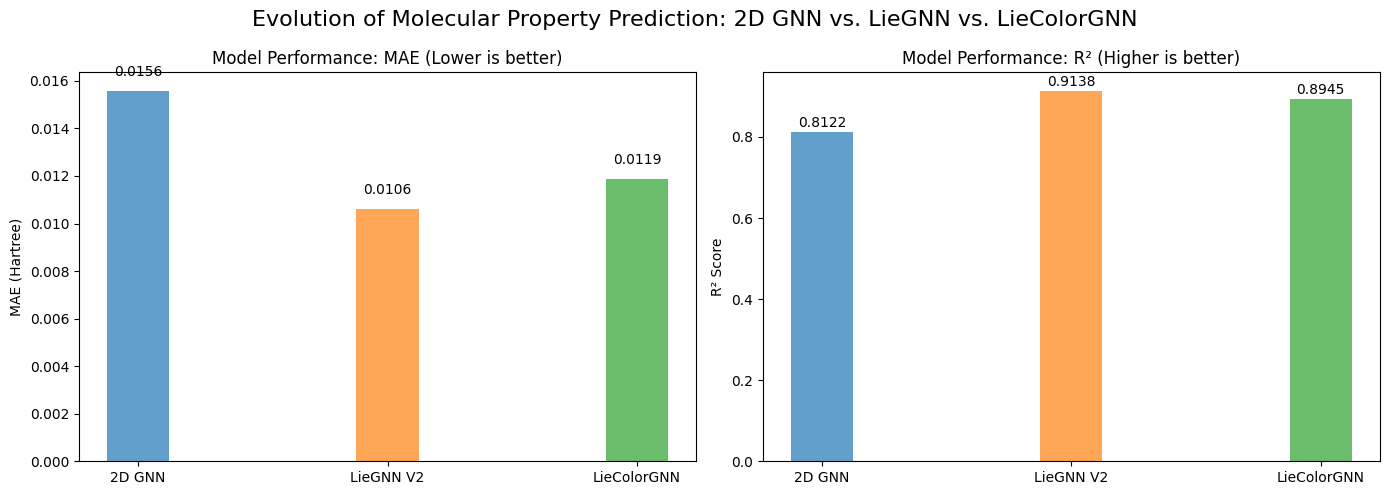

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Performance metrics - Ensure these variables are defined from your previous cells
# If for some reason a variable is missing, you can manually replace the values below
labels = ['2D GNN', 'LieGNN V2', 'LieColorGNN']
mae_scores = [mae, mae_3d_v2, mae_lc]
r2_scores = [r2, r2_3d_v2, r2_lc]

x = np.arange(len(labels))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot MAE (Lower is better)
bars1 = ax1.bar(x, mae_scores, width, color=['tab:blue', 'tab:orange', 'tab:green'], alpha=0.7)
ax1.set_ylabel('MAE (Hartree)')
ax1.set_title('Model Performance: MAE (Lower is better)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.0005, f"{yval:.4f}", ha='center', va='bottom')

# Plot R2 Score (Higher is better)
bars2 = ax2.bar(x, r2_scores, width, color=['tab:blue', 'tab:orange', 'tab:green'], alpha=0.7)
ax2.set_ylabel('R² Score')
ax2.set_title('Model Performance: R² (Higher is better)')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom')

plt.suptitle('Evolution of Molecular Property Prediction: 2D GNN vs. LieGNN vs. LieColorGNN', fontsize=16)
plt.tight_layout()
plt.show()